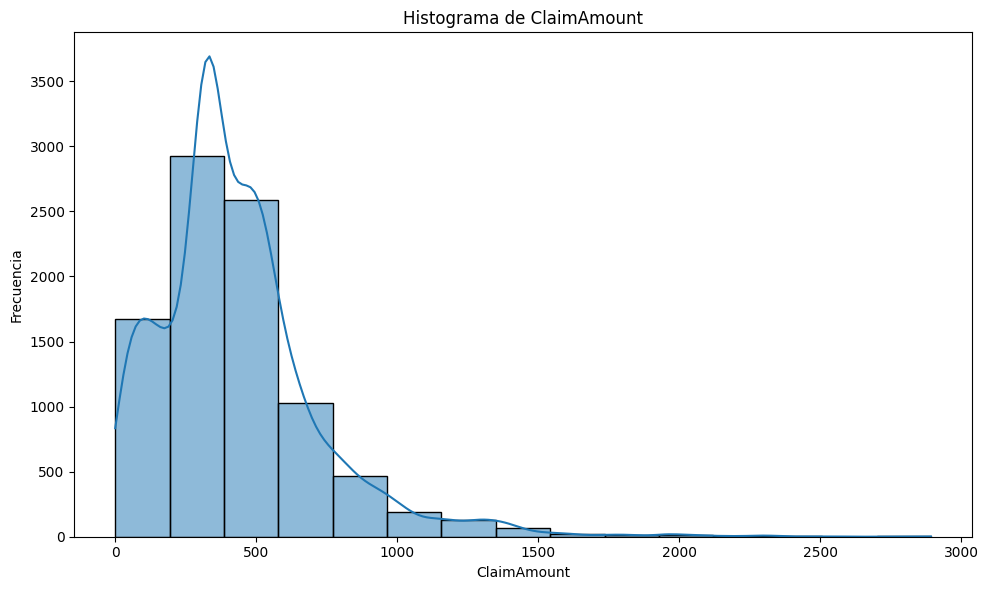

La variable ClaimAmount presenta una distribución sesgada a la derecha (positivamente sesgada o asimétrica positiva).


In [10]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
from scipy.stats import zscore, skew, kurtosis

# Cargar datos
df = pd.read_csv("customer.csv")
df = df.loc[:, ~df.columns.str.contains('^Unnamed')]

# ¿Cuál es el tipo de distribución que presenta `ClaimAmount`?
plt.figure(figsize=(10, 6))
sns.histplot(df['ClaimAmount'], kde=True, bins=15)
plt.title('Histograma de ClaimAmount')
plt.xlabel('ClaimAmount')
plt.ylabel('Frecuencia')
plt.tight_layout()
plt.show()
print("La variable ClaimAmount presenta una distribución sesgada a la derecha (positivamente sesgada o asimétrica positiva).")

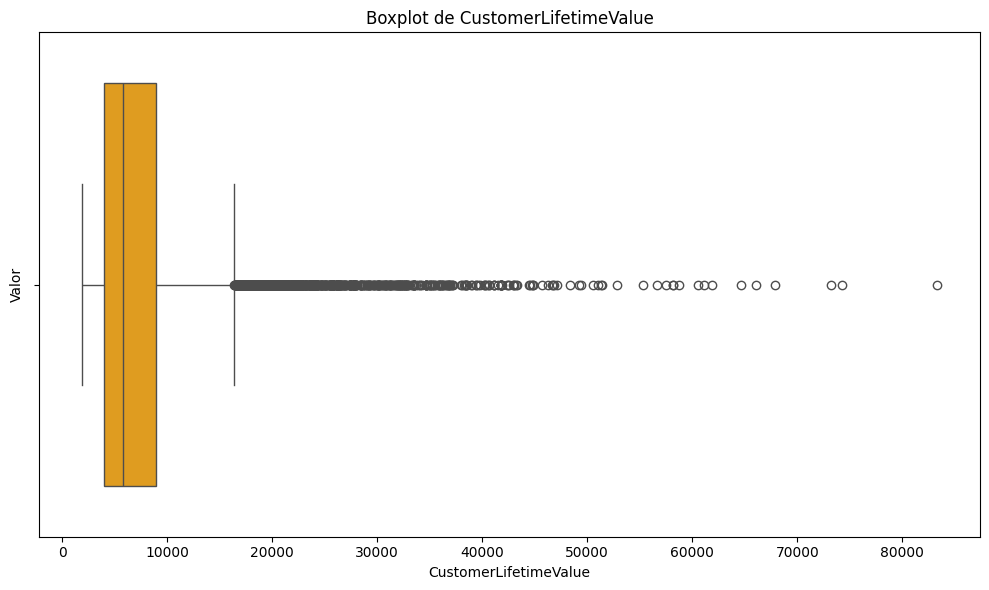

In [7]:
# Identificá si hay outliers en `CustomerLifetimeValue` usando visualización.
plt.figure(figsize=(10, 6))
sns.boxplot(x=df['CustomerLifetimeValue'], color='orange')
plt.title('Boxplot de CustomerLifetimeValue')
plt.xlabel('CustomerLifetimeValue')
plt.ylabel('Valor')
plt.tight_layout()
plt.show()
print("El boxplot muestra la presencia de outliers en CustomerLifetimeValue, ya que hay puntos que se encuentran fuera de los bigotes del boxplot.")



In [9]:
# Usá el método del IQR para detectar outliers en `MonthlyPremiumAuto`
Q1 = df['MonthlyPremiumAuto'].quantile(0.25)
Q3 = df['MonthlyPremiumAuto'].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR
outliers = df[(df['MonthlyPremiumAuto'] < lower_bound) | (df['MonthlyPremiumAuto'] > upper_bound)]
print(f"Número de outliers detectados en MonthlyPremiumAuto usando el método del IQR): {outliers.shape[0]}")

Número de outliers detectados en MonthlyPremiumAuto usando el método del IQR): 430


In [11]:
# Usá el método del Z-score en `ClaimAmount` y reportá cuántos outliers hay
z_scores = zscore(df['ClaimAmount'])
outliers_z = df[np.abs(z_scores) > 3]
print(f"Cantidad de outliers detectados por Z-score: {outliers_z.shape[0]}")

Cantidad de outliers detectados por Z-score: 158


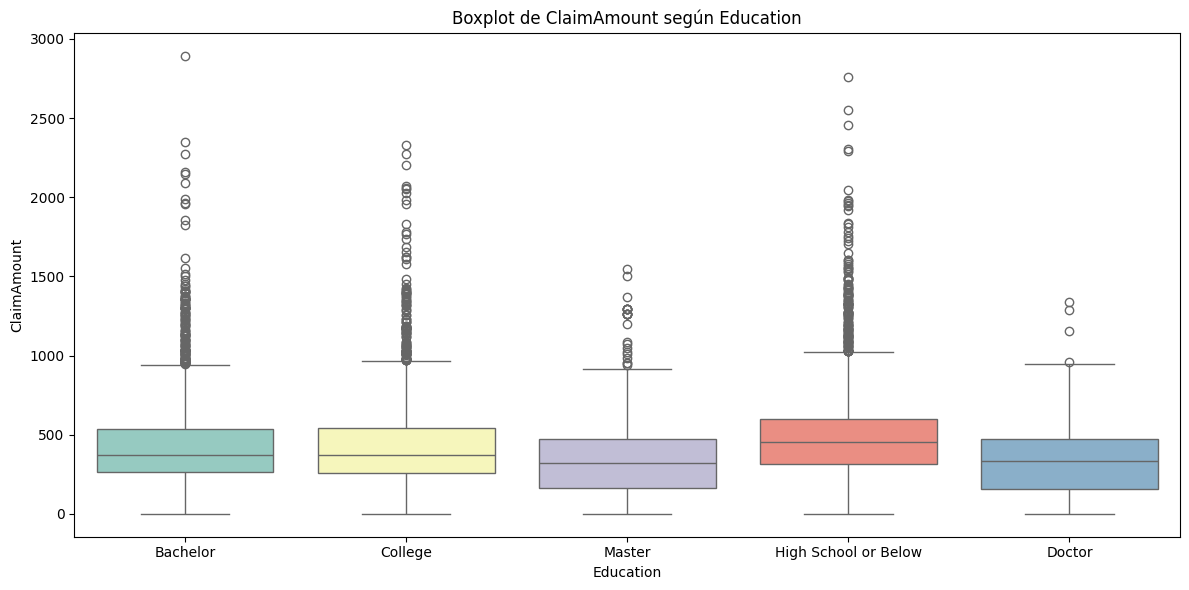

In [13]:
# Compará `ClaimAmount` según `Education` con un boxplot
plt.figure(figsize=(12, 6))
sns.boxplot(x='Education', y='ClaimAmount', data=df, hue='Education', palette='Set3')
plt.title('Boxplot de ClaimAmount según Education')
plt.xlabel('Education')
plt.ylabel('ClaimAmount')
plt.tight_layout()
plt.show()

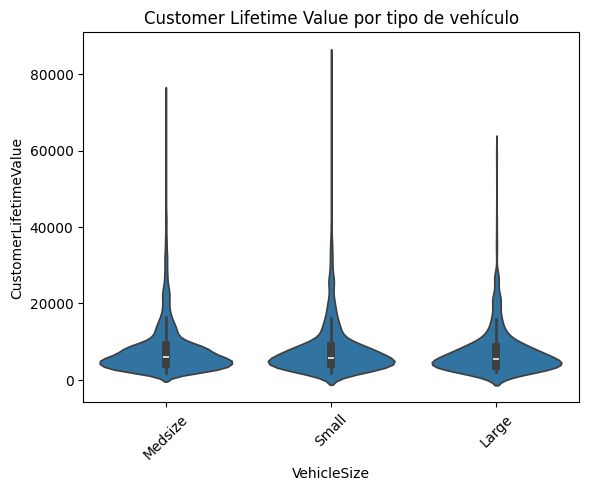

Esto sugiere que el tamaño del vehículo no tiene un impacto fuerte en el valor de vida del cliente en este dataset.


In [19]:
# ¿Qué diferencias ves entre `VehicleSize` y `CustomerLifetimeValue`?
sns.violinplot(x="VehicleSize", y="CustomerLifetimeValue", data=df)
plt.xticks(rotation=45)
plt.title("Customer Lifetime Value por tipo de vehículo")
plt.show()
print("Esto sugiere que el tamaño del vehículo no tiene un impacto fuerte en el valor de vida del cliente en este dataset.")


In [13]:
# Calculá y analizá la asimetría de `MonthlyPremiumAuto`
skewness = skew(df['MonthlyPremiumAuto'].dropna())
print(f"Asimetría de MonthlyPremiumAuto: {skewness}")
if skewness < 0:
    print("La asimetría es negativa, indicando que la cola izquierda es más larga o más pesada que la derecha.")
elif skewness == 0:
    print("La distribución es simétrica.")
else:
    print("La asimetría es positiva, indicando que la cola derecha es más larga o más pesada que la izquierda.")

Asimetría de MonthlyPremiumAuto: 2.123197701864424
La asimetría es positiva, indicando que la cola derecha es más larga o más pesada que la izquierda.


In [12]:
# ¿Qué indica la curtosis de `ClaimAmount`?
kurt = kurtosis(df['ClaimAmount'].dropna())
print(f"Curtosis de TotalClaimAmount: {kurt}")

# Interpretación de la curtosis
if kurt < 3:
    print("La distribución de ClaimAmount es platicúrtica (más plana que una normal).")
elif kurt == 3:
    print("La distribución de ClaimAmount es mesocúrtica (similar a una normal).")
else:
    print("La distribución de ClaimAmount es leptocúrtica (con más pico que una normal).")

Curtosis de TotalClaimAmount: 5.975471577225967
La distribución de ClaimAmount es leptocúrtica (con más pico que una normal).


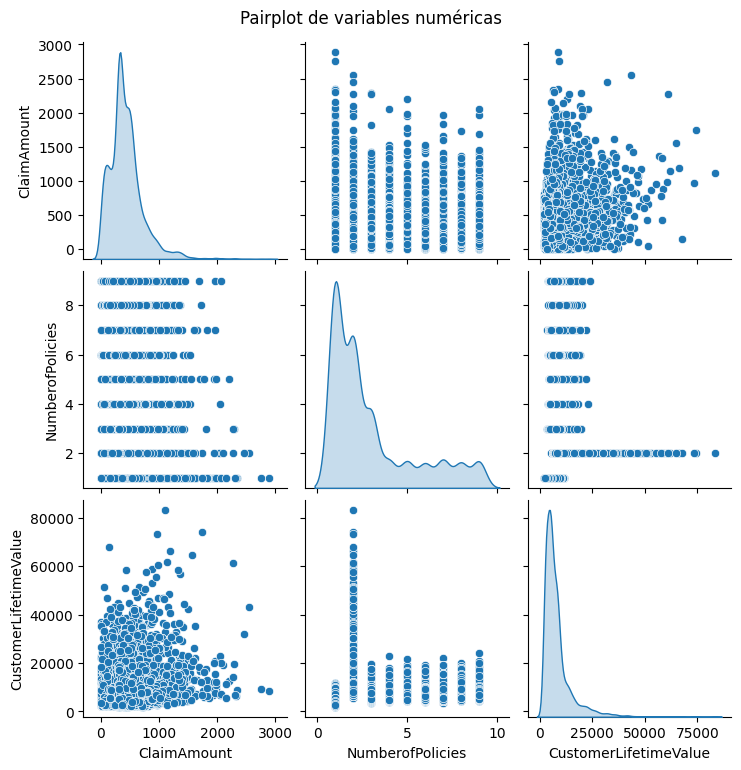

In [14]:
# Usá un `pairplot` con variables numéricas del dataset
sns.pairplot(df[["ClaimAmount", "NumberofPolicies", "CustomerLifetimeValue"]], diag_kind="kde")
plt.suptitle('Pairplot de variables numéricas', y=1.02)
plt.show()


In [16]:
# ¿Cómo puede afectar la presencia de outliers en un modelo predictivo?
print('''
La presencia de outliers puede afectar negativamente a un modelo predictivo de varias formas:
- Distorsión de los parámetros: Los outliers pueden influir mucho en la media y la varianza, afectando modelos sensibles como la regresión lineal.
- Menor precisión: El modelo puede ajustarse demasiado a los valores atípicos, perdiendo capacidad de generalización y aumentando el error en nuevas predicciones.
- Problemas en métricas: Las métricas de evaluación pueden verse alteradas, dando una falsa impresión del rendimiento real.
- Sobreajuste: El modelo puede aprender patrones erróneos debido a los outliers, lo que lleva a un sobreajuste (overfitting).
''')


La presencia de outliers puede afectar negativamente a un modelo predictivo de varias formas:
- Distorsión de los parámetros: Los outliers pueden influir mucho en la media y la varianza, afectando modelos sensibles como la regresión lineal.
- Menor precisión: El modelo puede ajustarse demasiado a los valores atípicos, perdiendo capacidad de generalización y aumentando el error en nuevas predicciones.
- Problemas en métricas: Las métricas de evaluación pueden verse alteradas, dando una falsa impresión del rendimiento real.
- Sobreajuste: El modelo puede aprender patrones erróneos debido a los outliers, lo que lleva a un sobreajuste (overfitting).

